In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [7]:


df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [13]:
df.groupby('sex')[['total_bill']].mean()

C:\Users\acer\AppData\Local\Temp\ipykernel_9332\2388094044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [26]:


df.groupby(['sex','smoker'])['total_bill'].mean().unstack()
df.groupby(['sex','smoker'])['total_bill'].mean()





C:\Users\acer\AppData\Local\Temp\ipykernel_9332\2982198490.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])['total_bill'].mean().unstack()
C:\Users\acer\AppData\Local\Temp\ipykernel_9332\2982198490.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])['total_bill'].mean()


sex     smoker
Male    Yes       22.284500
        No        19.791237
Female  Yes       17.977879
        No        18.105185
Name: total_bill, dtype: float64

In [30]:


# default aggregrate function is mean
df.pivot_table(index='sex',columns='smoker',values='total_bill')

C:\Users\acer\AppData\Local\Temp\ipykernel_9332\163715189.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [32]:



df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')

C:\Users\acer\AppData\Local\Temp\ipykernel_9332\1872891942.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')


smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [38]:

# extracting all columns 


df.pivot_table(index='sex',columns='smoker',values=['total_bill','tip','size'])

C:\Users\acer\AppData\Local\Temp\ipykernel_9332\3995073431.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values=['total_bill','tip','size'])


size                 tip           total_bill           
smoker       Yes        No       Yes        No        Yes         No
sex                                                                 
Male    2.500000  2.711340  3.051167  3.113402  22.284500  19.791237
Female  2.242424  2.592593  2.931515  2.773519  17.977879  18.105185

In [40]:



# multidimensional 

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [46]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],values=['total_bill','tip'])

C:\Users\acer\AppData\Local\Temp\ipykernel_9332\4279553785.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],values=['total_bill','tip'])


tip                                         total_bill  \
day                Thur          Fri              Sat       Sun       Thur   
time              Lunch Dinner Lunch Dinner    Dinner    Dinner      Lunch   
sex    smoker                                                                
Male   Yes     3.058000    NaN  1.90  3.246  2.879259  3.521333  19.171000   
       No      2.941500    NaN   NaN  2.500  3.256563  3.115349  18.486500   
Female Yes     2.990000    NaN  2.66  2.700  2.868667  3.500000  19.218571   
       No      2.437083    3.0  3.00  3.250  2.724615  3.329286  15.899167   

                                                               
day                         Fri                Sat        Sun  
time          Dinner      Lunch  Dinner     Dinner     Dinner  
sex    smoker                                                  
Male   Yes       NaN  11.386667  25.892  21.837778  26.141333  
       No        NaN        NaN  17.475  19.929063  20.403256  
Female Yes       NaN  13.260000  12.200  20.266667  16.540000  
       No      18.78  15.980000  22.750  19.003846  20.824286

In [48]:


df.pivot_table(index=['sex','smoker'],columns=['day','time'],values=['total_bill','tip'],aggfunc={'total_bill':'mean','tip':'max'})

C:\Users\acer\AppData\Local\Temp\ipykernel_9332\3125306110.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],values=['total_bill','tip'],aggfunc={'total_bill':'mean','tip':'max'})


tip                                   total_bill         \
day            Thur          Fri           Sat    Sun       Thur          
time          Lunch Dinner Lunch Dinner Dinner Dinner      Lunch Dinner   
sex    smoker                                                             
Male   Yes     5.00    NaN  2.20   4.73  10.00    6.5  19.171000    NaN   
       No      6.70    NaN   NaN   3.50   9.00    6.0  18.486500    NaN   
Female Yes     5.00    NaN  3.48   4.30   6.50    4.0  19.218571    NaN   
       No      5.17    3.0  3.00   3.25   4.67    5.2  15.899167  18.78   

                                                        
day                  Fri                Sat        Sun  
time               Lunch  Dinner     Dinner     Dinner  
sex    smoker                                           
Male   Yes     11.386667  25.892  21.837778  26.141333  
       No            NaN  17.475  19.929063  20.403256  
Female Yes     13.260000  12.200  20.266667  16.540000  
       No      15.980000  22.750  19.003846  20.824286

In [50]:


# margins  parameter basically sum the rows and columns

df.pivot_table(index='sex',columns='smoker',values=['total_bill','tip','size'],margins=True)

C:\Users\acer\AppData\Local\Temp\ipykernel_9332\1220304014.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values=['total_bill','tip','size'],margins=True)


size                           tip                     total_bill  \
smoker       Yes        No       All       Yes        No       All        Yes   
sex                                                                             
Male    2.500000  2.711340  2.630573  3.051167  3.113402  3.089618  22.284500   
Female  2.242424  2.592593  2.459770  2.931515  2.773519  2.833448  17.977879   
All     2.408602  2.668874  2.569672  3.008710  2.991854  2.998279  20.756344   

                              
smoker         No        All  
sex                           
Male    19.791237  20.744076  
Female  18.105185  18.056897  
All     19.188278  19.785943

In [54]:




# plotting graphs 


expense=pd.read_csv(r"C:\Users\acer\Python-Sql-1\numpy_pandas_matplotlib_seaborn\dataset for pivot_table and vectorized strings\expense_data.csv")
expense.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [56]:
expense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [58]:
#converting object(string) to datetime
# using datetime() function'


expense['Date']=pd.to_datetime(expense['Date'])
expense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [60]:



# extracting month from date time

# extracting month and  storing in neew column 

expense['Month']=expense['Date'].dt.month_name()




# here dt is datetime acessor in pandas
expense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
 11  Month           277 non-null    object        
dtypes: datetime64[ns](1), float64(5), object(6)
memory usage: 26.1+ KB


In [62]:


expense.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


<Axes: xlabel='Month'>

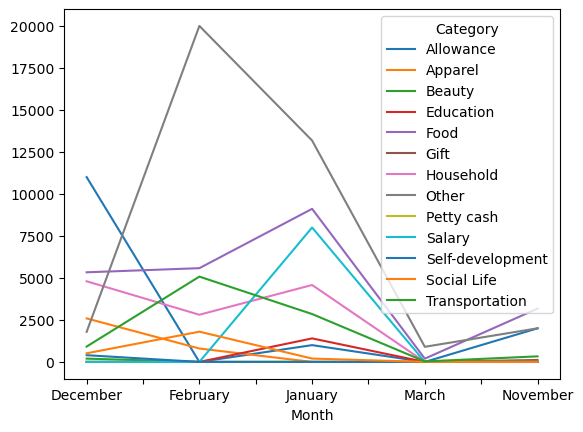

In [70]:
expense.pivot_table(index='Month',columns='Category',values='Amount',aggfunc='sum',fill_value=0).plot()

<Axes: xlabel='Month'>

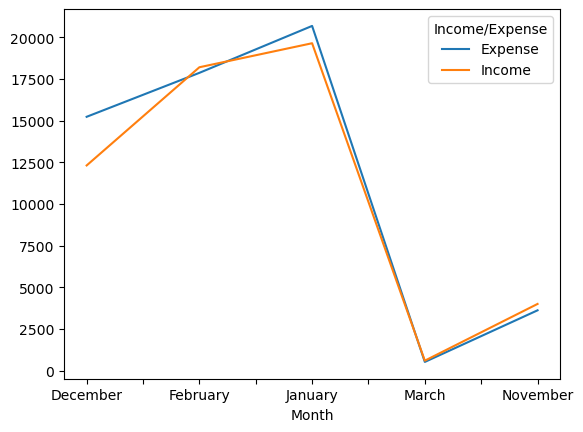

In [72]:



expense.pivot_table(index='Month',columns='Income/Expense',values='Amount',aggfunc='sum',fill_value=0).plot()